# Stage 3 — Production Planning Optimization

This notebook evaluates a 13-week multi-SKU production-planning model
driven by demand forecasts from the forecasting stage.

The optimization model determines weekly SKU-level production,
inventory, and backlog decisions subject to shared plant capacity
constraints.

The model is formulated in Pyomo and solved using HiGHS.

The objective is to minimize:

- production cost,
- inventory holding cost,
- shortage/backlog cost,

while satisfying the inventory-flow equations and production-capacity
constraints.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:

    current = Path.cwd().resolve()

    for candidate in [
        current,
        *current.parents,
    ]:

        if (
            candidate
            / "pyproject.toml"
        ).exists():

            return candidate

    raise FileNotFoundError(
        "Could not locate project root."
    )


PROJECT_ROOT = find_project_root()

OPTIMIZATION_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "optimization"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nOptimization artifacts:")
print(OPTIMIZATION_DIR)

Project root:
T:\Tanmay@IITK\Projects\new_demfor_planopti

Optimization artifacts:
T:\Tanmay@IITK\Projects\new_demfor_planopti\data\processed\optimization


In [2]:
forecast = pd.read_parquet(
    OPTIMIZATION_DIR
    / "optimization_forecast.parquet"
)

production_plan = pd.read_parquet(
    OPTIMIZATION_DIR
    / "production_plan.parquet"
)

sku_parameters = pd.read_csv(
    OPTIMIZATION_DIR
    / "sku_parameters.csv"
)

capacity = pd.read_csv(
    OPTIMIZATION_DIR
    / "capacity.csv"
)

executive_summary = pd.read_csv(
    OPTIMIZATION_DIR
    / "executive_summary.csv"
)

cost_summary = pd.read_csv(
    OPTIMIZATION_DIR
    / "cost_summary.csv"
)

capacity_summary = pd.read_csv(
    OPTIMIZATION_DIR
    / "capacity_summary.csv"
)

capacity_detail = pd.read_csv(
    OPTIMIZATION_DIR
    / "capacity_detail.csv"
)

sku_summary = pd.read_csv(
    OPTIMIZATION_DIR
    / "sku_summary.csv"
)


for frame in [
    forecast,
    production_plan,
    capacity,
    capacity_detail,
]:

    if "week_start" in frame.columns:

        frame["week_start"] = pd.to_datetime(
            frame["week_start"]
        )


print(
    "Forecast rows:",
    len(forecast),
)

print(
    "Plan rows:",
    len(production_plan),
)

print(
    "SKUs:",
    forecast["sku_id"].nunique(),
)

print(
    "Weeks:",
    forecast[
        "forecast_horizon"
    ].nunique(),
)

Forecast rows: 260
Plan rows: 260
SKUs: 20
Weeks: 13


In [3]:
assert len(forecast) == 20 * 13

assert len(production_plan) == 20 * 13

assert (
    forecast["sku_id"].nunique()
    == 20
)

assert (
    forecast[
        "forecast_horizon"
    ].nunique()
    == 13
)

assert (
    executive_summary.loc[
        0,
        "termination_condition",
    ]
    == "optimal"
)

assert np.isclose(
    production_plan[
        "total_cost"
    ].sum(),
    executive_summary.loc[
        0,
        "objective_value",
    ],
)

print(
    "Forecast → optimization "
    "integration contract passed."
)

Forecast → optimization integration contract passed.


## 1. Optimization result overview

The baseline planning scenario assumes:

- initial inventory equal to 0.10 weeks of average forecast demand,
- constant plant capacity equal to average forecast workload,
- positive inventory holding cost,
- shortage cost substantially above holding cost.

This creates a capacity-constrained planning problem in which the
optimizer can prebuild inventory during available periods to avoid
future shortages.

In [4]:
executive_summary.T

,0
solver_status,ok
termination_condition,optimal
objective_value,678779.894205
total_forecast_demand,136728.164538
initial_backlog,0.0
total_demand_obligation,136728.164538
total_production,135676.409438
final_inventory,0.0
final_backlog,0.0
portfolio_service_pct,100.0


In [5]:
executive_summary.T

,0
solver_status,ok
termination_condition,optimal
objective_value,678779.894205
total_forecast_demand,136728.164538
initial_backlog,0.0
total_demand_obligation,136728.164538
total_production,135676.409438
final_inventory,0.0
final_backlog,0.0
portfolio_service_pct,100.0


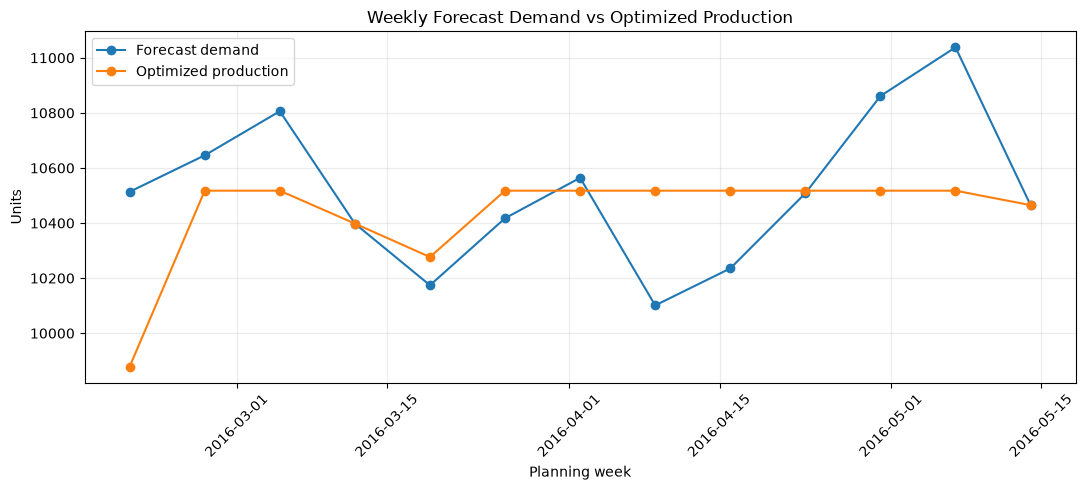

In [6]:
weekly_plan = (
    production_plan
    .groupby(
        [
            "week_start",
            "forecast_horizon",
        ],
        as_index=False,
    )
    .agg(
        forecast_demand=(
            "forecast_demand",
            "sum",
        ),
        production_quantity=(
            "production_quantity",
            "sum",
        ),
        ending_inventory=(
            "ending_inventory",
            "sum",
        ),
        ending_backlog=(
            "ending_backlog",
            "sum",
        ),
    )
)


fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    weekly_plan["week_start"],
    weekly_plan["forecast_demand"],
    marker="o",
    label="Forecast demand",
)

ax.plot(
    weekly_plan["week_start"],
    weekly_plan["production_quantity"],
    marker="o",
    label="Optimized production",
)

ax.set_title(
    "Weekly Forecast Demand vs Optimized Production"
)

ax.set_xlabel(
    "Planning week"
)

ax.set_ylabel(
    "Units"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

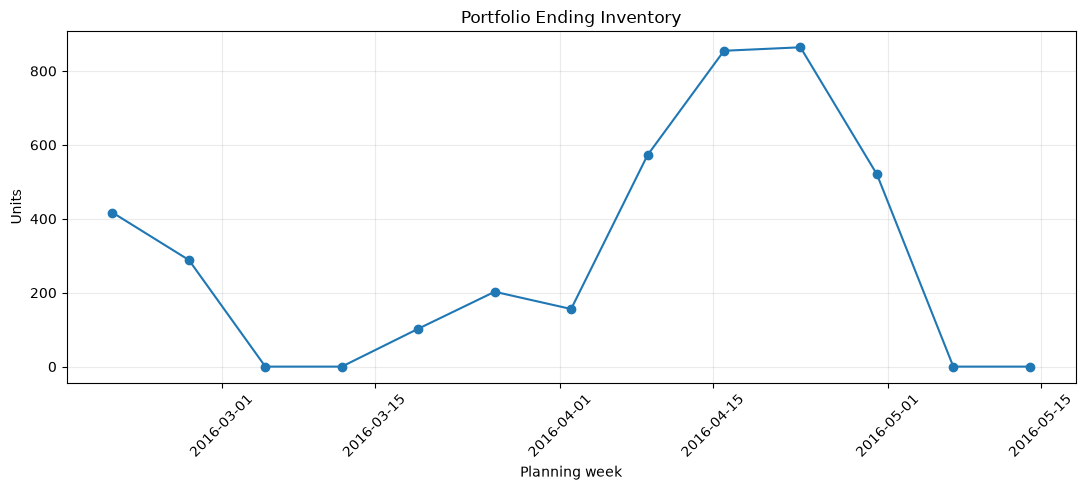

In [7]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    weekly_plan["week_start"],
    weekly_plan["ending_inventory"],
    marker="o",
)

ax.set_title(
    "Portfolio Ending Inventory"
)

ax.set_xlabel(
    "Planning week"
)

ax.set_ylabel(
    "Units"
)

ax.grid(
    alpha=0.25
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

## 9. Baseline planning policy vs optimized production plan

An optimization result is only useful if it improves upon a reasonable
non-optimized planning policy.

The benchmark used here is a **just-in-time proportional production
policy**:

- each week attempts to produce only the quantity currently required,
- available inventory is consumed before new production,
- existing backlog is included in the current requirement,
- no production is intentionally prebuilt for future demand,
- SKU production ceilings are respected,
- if total required production exceeds plant capacity, available
  capacity is allocated proportionally across current SKU requirements.

This policy obeys the same physical constraints as the optimization
model but has no look-ahead capability.

The comparison therefore measures the value of multi-period
optimization rather than comparing against an infeasible planning rule.

In [8]:
def build_jit_baseline(
    forecast: pd.DataFrame,
    sku_parameters: pd.DataFrame,
    capacity: pd.DataFrame,
) -> pd.DataFrame:
    """
    Non-anticipatory production baseline.

    The policy attempts to satisfy only current demand and outstanding
    backlog. It never deliberately prebuilds inventory for future weeks.
    """

    forecast = forecast.copy()
    sku_parameters = sku_parameters.copy()
    capacity = capacity.copy()

    forecast["week_start"] = pd.to_datetime(
        forecast["week_start"]
    )

    capacity["week_start"] = pd.to_datetime(
        capacity["week_start"]
    )

    parameters = (
        sku_parameters
        .set_index("sku_id")
    )

    skus = sorted(
        forecast["sku_id"].unique()
    )

    weeks = (
        forecast["week_start"]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    capacity_lookup = (
        capacity
        .set_index("week_start")[
            "production_capacity"
        ]
        .to_dict()
    )

    inventory = {
        sku_id: float(
            parameters.loc[
                sku_id,
                "initial_inventory",
            ]
        )
        for sku_id in skus
    }

    backlog = {
        sku_id: float(
            parameters.loc[
                sku_id,
                "initial_backlog",
            ]
        )
        for sku_id in skus
    }

    rows = []

    for horizon, week in enumerate(
        weeks,
        start=1,
    ):

        week_forecast = (
            forecast.loc[
                forecast["week_start"].eq(
                    week
                )
            ]
            .set_index("sku_id")[
                "forecast_demand"
            ]
        )

        # ----------------------------------------------------
        # Current production requirement only.
        #
        # No forecast demand from future weeks is considered.
        # ----------------------------------------------------

        desired_production = {}

        for sku_id in skus:

            demand = float(
                week_forecast.loc[
                    sku_id
                ]
            )

            current_requirement = max(
                0.0,
                demand
                + backlog[sku_id]
                - inventory[sku_id],
            )

            max_production = float(
                parameters.loc[
                    sku_id,
                    "max_production_per_week",
                ]
            )

            desired_production[
                sku_id
            ] = min(
                current_requirement,
                max_production,
            )

        # ----------------------------------------------------
        # Shared plant capacity.
        # ----------------------------------------------------

        desired_capacity = sum(
            desired_production[sku_id]
            * float(
                parameters.loc[
                    sku_id,
                    "processing_time",
                ]
            )
            for sku_id in skus
        )

        available_capacity = float(
            capacity_lookup[
                pd.Timestamp(week)
            ]
        )

        if desired_capacity <= 0:

            scale = 0.0

        else:

            scale = min(
                1.0,
                available_capacity
                / desired_capacity,
            )

        # ----------------------------------------------------
        # Execute production and update inventory/backlog.
        # ----------------------------------------------------

        for sku_id in skus:

            demand = float(
                week_forecast.loc[
                    sku_id
                ]
            )

            production = (
                desired_production[
                    sku_id
                ]
                * scale
            )

            previous_inventory = (
                inventory[
                    sku_id
                ]
            )

            previous_backlog = (
                backlog[
                    sku_id
                ]
            )

            net_inventory = (
                previous_inventory
                - previous_backlog
                + production
                - demand
            )

            ending_inventory = max(
                net_inventory,
                0.0,
            )

            ending_backlog = max(
                -net_inventory,
                0.0,
            )

            inventory[
                sku_id
            ] = ending_inventory

            backlog[
                sku_id
            ] = ending_backlog

            production_cost = (
                production
                * float(
                    parameters.loc[
                        sku_id,
                        "unit_production_cost",
                    ]
                )
            )

            holding_cost = (
                ending_inventory
                * float(
                    parameters.loc[
                        sku_id,
                        "unit_holding_cost",
                    ]
                )
            )

            shortage_cost = (
                ending_backlog
                * float(
                    parameters.loc[
                        sku_id,
                        "unit_shortage_cost",
                    ]
                )
            )

            capacity_used = (
                production
                * float(
                    parameters.loc[
                        sku_id,
                        "processing_time",
                    ]
                )
            )

            rows.append(
                {
                    "week_start":
                        pd.Timestamp(week),

                    "forecast_horizon":
                        horizon,

                    "sku_id":
                        sku_id,

                    "forecast_demand":
                        demand,

                    "production_quantity":
                        production,

                    "ending_inventory":
                        ending_inventory,

                    "ending_backlog":
                        ending_backlog,

                    "capacity_used":
                        capacity_used,

                    "production_cost":
                        production_cost,

                    "holding_cost":
                        holding_cost,

                    "shortage_cost":
                        shortage_cost,

                    "total_cost":
                        (
                            production_cost
                            + holding_cost
                            + shortage_cost
                        ),
                }
            )

    baseline = pd.DataFrame(
        rows
    )

    return (
        baseline
        .sort_values(
            [
                "forecast_horizon",
                "sku_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )


jit_baseline = build_jit_baseline(
    forecast=forecast,
    sku_parameters=sku_parameters,
    capacity=capacity,
)

jit_baseline.head()

,week_start,forecast_horizon,sku_id,forecast_demand,production_quantity,ending_inventory,ending_backlog,capacity_used,production_cost,holding_cost,shortage_cost,total_cost
0,2016-02-20,1,FOODS_2_197,255.280903,229.719903,0.0,-0.0,229.719903,1148.599515,0.0,-0.0,1148.599515
1,2016-02-20,1,FOODS_3_080,330.266037,296.350537,0.0,-0.0,296.350537,1481.752684,0.0,-0.0,1481.752684
2,2016-02-20,1,FOODS_3_090,1455.635157,1321.767457,0.0,-0.0,1321.767457,6608.837283,0.0,-0.0,6608.837283
3,2016-02-20,1,FOODS_3_120,1018.645011,916.776211,0.0,-0.0,916.776211,4583.881055,0.0,-0.0,4583.881055
4,2016-02-20,1,FOODS_3_202,417.360697,380.199097,0.0,-0.0,380.199097,1900.995485,0.0,-0.0,1900.995485


In [9]:
baseline_capacity = (
    jit_baseline
    .groupby(
        "week_start",
        as_index=False,
    )
    .agg(
        capacity_used=(
            "capacity_used",
            "sum",
        )
    )
    .merge(
        capacity,
        on="week_start",
        how="left",
        validate="one_to_one",
    )
)

assert (
    baseline_capacity[
        "capacity_used"
    ]
    <=
    baseline_capacity[
        "production_capacity"
    ]
    + 1e-6
).all()

assert (
    jit_baseline[
        "production_quantity"
    ]
    >= -1e-8
).all()

assert (
    jit_baseline[
        "ending_inventory"
    ]
    >= -1e-8
).all()

assert (
    jit_baseline[
        "ending_backlog"
    ]
    >= -1e-8
).all()

print(
    "JIT baseline feasibility contract passed."
)

JIT baseline feasibility contract passed.


In [10]:
def planning_metrics(
    plan: pd.DataFrame,
    sku_parameters: pd.DataFrame,
    capacity: pd.DataFrame,
) -> dict[str, float]:

    final_state = (
        plan
        .sort_values(
            "forecast_horizon"
        )
        .groupby(
            "sku_id",
            observed=True,
        )
        .tail(1)
    )

    total_demand = float(
        plan[
            "forecast_demand"
        ].sum()
    )

    initial_backlog = float(
        sku_parameters[
            "initial_backlog"
        ].sum()
    )

    final_backlog = float(
        final_state[
            "ending_backlog"
        ].sum()
    )

    final_inventory = float(
        final_state[
            "ending_inventory"
        ].sum()
    )

    obligation = (
        total_demand
        + initial_backlog
    )

    service_pct = (
        100.0
        if obligation <= 0
        else
        100.0
        * (
            1.0
            - final_backlog
            / obligation
        )
    )

    total_available_capacity = float(
        capacity[
            "production_capacity"
        ].sum()
    )

    total_capacity_used = float(
        plan[
            "capacity_used"
        ].sum()
    )

    return {
        "total_cost":
            float(
                plan[
                    "total_cost"
                ].sum()
            ),

        "production_cost":
            float(
                plan[
                    "production_cost"
                ].sum()
            ),

        "holding_cost":
            float(
                plan[
                    "holding_cost"
                ].sum()
            ),

        "shortage_cost":
            float(
                plan[
                    "shortage_cost"
                ].sum()
            ),

        "total_production":
            float(
                plan[
                    "production_quantity"
                ].sum()
            ),

        "final_inventory":
            final_inventory,

        "final_backlog":
            final_backlog,

        "service_pct":
            service_pct,

        "capacity_utilization_pct":
            (
                100.0
                * total_capacity_used
                / total_available_capacity
            ),
    }


optimized_metrics = planning_metrics(
    plan=production_plan,
    sku_parameters=sku_parameters,
    capacity=capacity,
)

baseline_metrics = planning_metrics(
    plan=jit_baseline,
    sku_parameters=sku_parameters,
    capacity=capacity,
)


comparison = pd.DataFrame(
    [
        {
            "strategy":
                "JIT baseline",
            **baseline_metrics,
        },
        {
            "strategy":
                "Pyomo optimized",
            **optimized_metrics,
        },
    ]
)

comparison.round(2)

,strategy,total_cost,production_cost,holding_cost,shortage_cost,total_production,final_inventory,final_backlog,service_pct,capacity_utilization_pct
0,JIT baseline,732501.43,674323.40,0.00,58178.03,134864.68,0.0,811.73,99.41,98.64
1,Pyomo optimized,678779.89,678382.05,397.85,0.00,135676.41,0.0,0.00,100.00,99.23


In [11]:
baseline_cost = (
    baseline_metrics[
        "total_cost"
    ]
)

optimized_cost = (
    optimized_metrics[
        "total_cost"
    ]
)

cost_savings = (
    baseline_cost
    - optimized_cost
)

cost_savings_pct = (
    100.0
    * cost_savings
    / baseline_cost
)

service_improvement = (
    optimized_metrics[
        "service_pct"
    ]
    -
    baseline_metrics[
        "service_pct"
    ]
)

print(
    f"Baseline cost: "
    f"{baseline_cost:,.2f}"
)

print(
    f"Optimized cost: "
    f"{optimized_cost:,.2f}"
)

print(
    f"Cost savings: "
    f"{cost_savings:,.2f}"
)

print(
    f"Relative cost reduction: "
    f"{cost_savings_pct:.2f}%"
)

print(
    f"Service improvement: "
    f"{service_improvement:.2f} "
    f"percentage points"
)

Baseline cost: 732,501.43
Optimized cost: 678,779.89
Cost savings: 53,721.54
Relative cost reduction: 7.33%
Service improvement: 0.59 percentage points


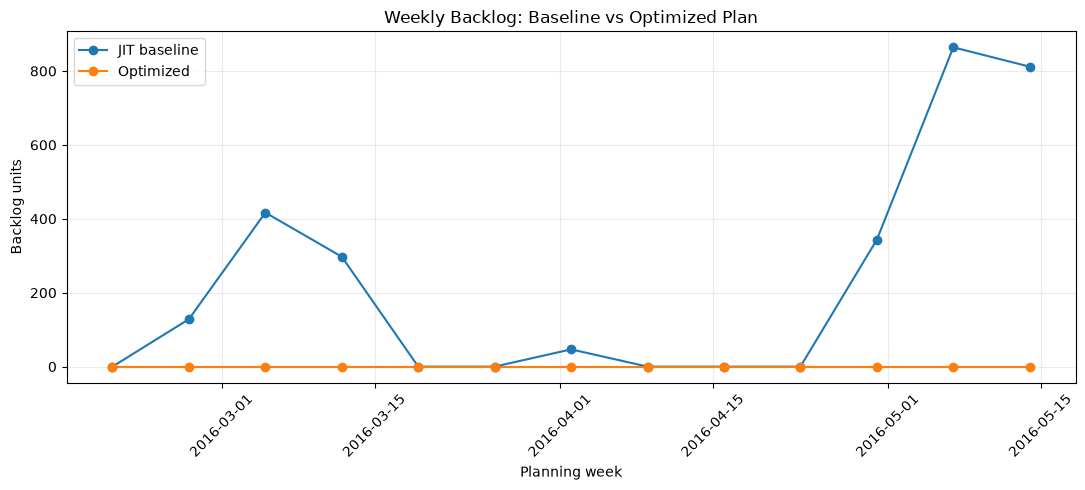

In [12]:
weekly_baseline = (
    jit_baseline
    .groupby(
        "week_start",
        as_index=False,
    )
    .agg(
        ending_backlog=(
            "ending_backlog",
            "sum",
        )
    )
)

weekly_optimized = (
    production_plan
    .groupby(
        "week_start",
        as_index=False,
    )
    .agg(
        ending_backlog=(
            "ending_backlog",
            "sum",
        )
    )
)


fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    weekly_baseline[
        "week_start"
    ],
    weekly_baseline[
        "ending_backlog"
    ],
    marker="o",
    label="JIT baseline",
)

ax.plot(
    weekly_optimized[
        "week_start"
    ],
    weekly_optimized[
        "ending_backlog"
    ],
    marker="o",
    label="Optimized",
)

ax.set_title(
    "Weekly Backlog: Baseline vs Optimized Plan"
)

ax.set_xlabel(
    "Planning week"
)

ax.set_ylabel(
    "Backlog units"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

## 10. Capacity sensitivity analysis

The baseline optimization assumes fixed weekly plant capacity equal to
the average forecast workload.

To quantify the value of capacity, the same production-planning model
is resolved under four capacity scenarios:

- 5% below baseline capacity,
- baseline capacity,
- 5% above baseline capacity,
- 10% above baseline capacity.

All other inputs—including demand forecasts, initial inventory, SKU
production limits, processing times, and cost parameters—are held
constant.

This isolates the effect of plant capacity on:

- total optimized cost,
- inventory holding,
- backlog and shortage cost,
- horizon service,
- capacity utilization,
- constrained weeks.

In [15]:
from new_demfor_planopti.optimization import (
    PlanningConfig,
    build_planning_report,
    solve_production_plan,
)


# ============================================================
# CAPACITY SCENARIOS
# ============================================================

capacity_scenarios = {
    "Capacity -5%": 0.95,
    "Baseline": 1.00,
    "Capacity +5%": 1.05,
    "Capacity +10%": 1.10,
}


planning_config = PlanningConfig(
    planning_horizon=13
)


scenario_rows = []
scenario_plans = {}


for scenario_name, multiplier in capacity_scenarios.items():

    scenario_capacity = (
        capacity.copy()
    )

    scenario_capacity[
        "production_capacity"
    ] = (
        scenario_capacity[
            "production_capacity"
        ]
        * multiplier
    )

    result = solve_production_plan(
        forecast=forecast,
        sku_parameters=sku_parameters,
        capacity=scenario_capacity,
        config=planning_config,
        tee=False,
    )

    report = build_planning_report(
        result=result,
        sku_parameters=sku_parameters,
    )

    executive = (
        report.executive_summary
        .iloc[0]
    )

    costs = (
        report.cost_summary
        .set_index(
            "cost_component"
        )["cost"]
    )

    scenario_rows.append(
        {
            "scenario":
                scenario_name,

            "capacity_multiplier":
                multiplier,

            "total_cost":
                result.objective_value,

            "production_cost":
                costs.loc[
                    "production"
                ],

            "holding_cost":
                costs.loc[
                    "holding"
                ],

            "shortage_cost":
                costs.loc[
                    "shortage"
                ],

            "total_production":
                executive[
                    "total_production"
                ],

            "final_inventory":
                executive[
                    "final_inventory"
                ],

            "final_backlog":
                executive[
                    "final_backlog"
                ],

            "service_pct":
                executive[
                    "portfolio_service_pct"
                ],

            "overall_utilization_pct":
                executive[
                    "overall_capacity_utilization_pct"
                ],

            "peak_utilization_pct":
                executive[
                    "peak_capacity_utilization_pct"
                ],

            "constrained_weeks":
                executive[
                    "constrained_weeks"
                ],
        }
    )

    scenario_plans[
        scenario_name
    ] = result.plan.copy()


capacity_sensitivity = pd.DataFrame(
    scenario_rows
)

capacity_sensitivity.round(2)

,scenario,capacity_multiplier,total_cost,production_cost,holding_cost,shortage_cost,total_production,final_inventory,final_backlog,service_pct,overall_utilization_pct,peak_utilization_pct,constrained_weeks
0,Capacity -5%,0.95,1303217.16,649458.78,52.99,653705.39,129891.76,0.0,5784.65,95.77,100.00,100.00,13
1,Baseline,1.00,678779.89,678382.05,397.85,0.00,135676.41,0.0,0.00,100.00,99.23,100.00,10
2,Capacity +5%,1.05,678382.05,678382.05,0.00,0.00,135676.41,0.0,0.00,100.00,94.51,99.95,1
3,Capacity +10%,1.10,678382.05,678382.05,0.00,0.00,135676.41,0.0,0.00,100.00,90.21,95.41,0


In [16]:
baseline_scenario_cost = float(
    capacity_sensitivity.loc[
        capacity_sensitivity[
            "scenario"
        ].eq(
            "Baseline"
        ),
        "total_cost",
    ].iloc[0]
)


capacity_sensitivity[
    "cost_change_vs_baseline"
] = (
    capacity_sensitivity[
        "total_cost"
    ]
    -
    baseline_scenario_cost
)


capacity_sensitivity[
    "cost_change_pct_vs_baseline"
] = (
    100.0
    *
    capacity_sensitivity[
        "cost_change_vs_baseline"
    ]
    /
    baseline_scenario_cost
)


capacity_sensitivity[
    [
        "scenario",
        "total_cost",
        "cost_change_vs_baseline",
        "cost_change_pct_vs_baseline",
        "holding_cost",
        "shortage_cost",
        "final_backlog",
        "service_pct",
        "overall_utilization_pct",
        "constrained_weeks",
    ]
].round(2)

,scenario,total_cost,cost_change_vs_baseline,cost_change_pct_vs_baseline,holding_cost,shortage_cost,final_backlog,service_pct,overall_utilization_pct,constrained_weeks
0,Capacity -5%,1303217.16,624437.27,91.99,52.99,653705.39,5784.65,95.77,100.00,13
1,Baseline,678779.89,0.00,0.00,397.85,0.00,0.00,100.00,99.23,10
2,Capacity +5%,678382.05,-397.85,-0.06,0.00,0.00,0.00,100.00,94.51,1
3,Capacity +10%,678382.05,-397.85,-0.06,0.00,0.00,0.00,100.00,90.21,0


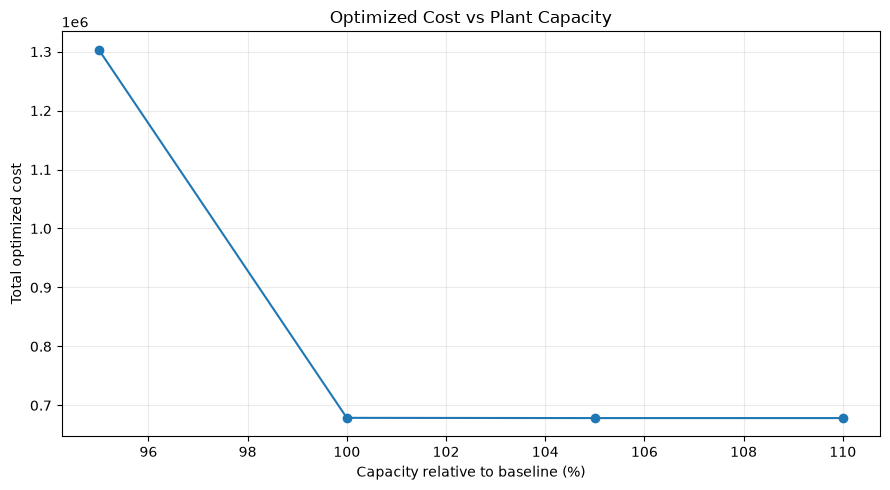

In [17]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    capacity_sensitivity[
        "capacity_multiplier"
    ]
    * 100,
    capacity_sensitivity[
        "total_cost"
    ],
    marker="o",
)

ax.set_title(
    "Optimized Cost vs Plant Capacity"
)

ax.set_xlabel(
    "Capacity relative to baseline (%)"
)

ax.set_ylabel(
    "Total optimized cost"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

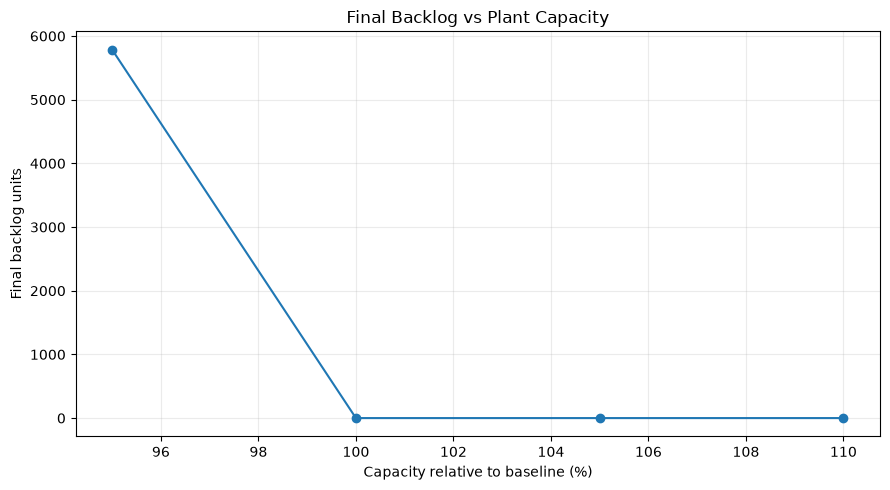

In [19]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    capacity_sensitivity[
        "capacity_multiplier"
    ]
    * 100,
    capacity_sensitivity[
        "final_backlog"
    ],
    marker="o",
)

ax.set_title(
    "Final Backlog vs Plant Capacity"
)

ax.set_xlabel(
    "Capacity relative to baseline (%)"
)

ax.set_ylabel(
    "Final backlog units"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

In [20]:
capacity_detail = pd.read_csv(
    OPTIMIZATION_DIR
    / "capacity_detail.csv"
)

capacity_detail[
    [
        "week_start",
        "production_capacity",
        "capacity_used",
        "utilization_pct",
        "capacity_dual",
        "capacity_marginal_value",
    ]
].round(3)

,week_start,production_capacity,capacity_used,utilization_pct,capacity_dual,capacity_marginal_value
0,2016-02-20,10517.551,9878.707,93.926,-0.0,0.0
1,2016-02-27,10517.551,10517.551,100.000,-0.1,0.1
2,2016-03-05,10517.551,10517.551,100.000,-0.2,0.2
3,2016-03-12,10517.551,10398.044,98.864,-0.0,0.0
4,2016-03-19,10517.551,10276.609,97.709,-0.0,0.0
5,2016-03-26,10517.551,10517.551,100.000,-0.1,0.1
6,2016-04-02,10517.551,10517.551,100.000,-0.2,0.2
7,2016-04-09,10517.551,10517.551,100.000,-0.3,0.3
8,2016-04-16,10517.551,10517.551,100.000,-0.4,0.4
9,2016-04-23,10517.551,10517.551,100.000,-0.5,0.5


## 11. Economic value of plant capacity

Because the production-planning formulation is a continuous linear
program, HiGHS provides dual values for the weekly plant-capacity
constraints.

The capacity marginal value measures the approximate reduction in
optimized cost from one additional unit of capacity in a given week,
holding the current LP basis locally fixed.

A capacity constraint may be physically binding without having a large
economic shadow value. Therefore utilization and marginal value provide
complementary information:

- utilization identifies physical bottlenecks,
- shadow prices identify economically valuable bottlenecks.

In the baseline scenario, marginal values rise toward the late-April
and early-May demand peak. This reflects the cost of producing units in
earlier weeks and carrying them as inventory: additional capacity closer
to the demand peak reduces the need for inventory prebuilding and avoids
multiple weeks of holding cost.

Shadow prices are local sensitivity measures and should not be
extrapolated over large changes in capacity.

In [21]:
capacity_detail[
    [
        "week_start",
        "production_capacity",
        "capacity_used",
        "utilization_pct",
        "capacity_marginal_value",
    ]
].round(2)

,week_start,production_capacity,capacity_used,utilization_pct,capacity_marginal_value
0,2016-02-20,10517.55,9878.71,93.93,0.0
1,2016-02-27,10517.55,10517.55,100.00,0.1
2,2016-03-05,10517.55,10517.55,100.00,0.2
3,2016-03-12,10517.55,10398.04,98.86,0.0
4,2016-03-19,10517.55,10276.61,97.71,0.0
5,2016-03-26,10517.55,10517.55,100.00,0.1
6,2016-04-02,10517.55,10517.55,100.00,0.2
7,2016-04-09,10517.55,10517.55,100.00,0.3
8,2016-04-16,10517.55,10517.55,100.00,0.4
9,2016-04-23,10517.55,10517.55,100.00,0.5


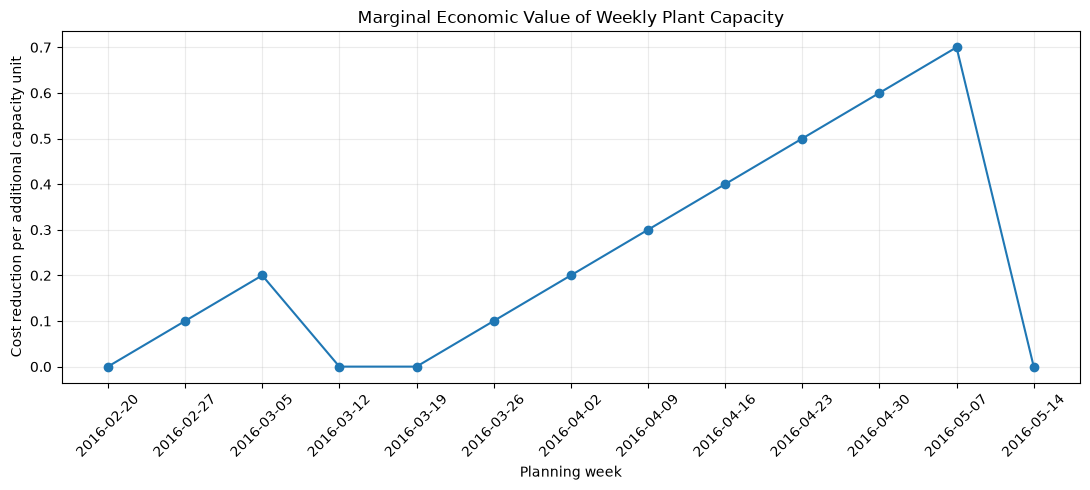

In [23]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    capacity_detail["week_start"],
    capacity_detail[
        "capacity_marginal_value"
    ],
    marker="o",
)

ax.set_title(
    "Marginal Economic Value of Weekly Plant Capacity"
)

ax.set_xlabel(
    "Planning week"
)

ax.set_ylabel(
    "Cost reduction per additional capacity unit"
)

ax.grid(
    alpha=0.25
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

## Final production-planning conclusions

The forecasting output was integrated with a 13-week multi-SKU
production-planning linear program formulated in Pyomo and solved with
HiGHS.

The model jointly optimized weekly production, inventory, and backlog
decisions subject to SKU production limits and a shared plant-capacity
constraint.

### Optimized baseline scenario

Under the baseline constrained-capacity scenario:

- total forecast demand was approximately 136.7k units,
- overall plant utilization was 99.23%,
- 10 of 13 planning weeks were capacity constrained,
- the optimizer achieved zero final backlog,
- planning-horizon service reached 100%.

The optimizer deliberately produced ahead of several demand peaks and
carried inventory between weeks. This incurred approximately 398 units
of holding cost but avoided shortage penalties.

### Value versus a non-anticipatory planning policy

A feasible JIT benchmark using the same plant constraints but without
future-demand look-ahead produced a total planning cost of approximately
732.5k.

The optimized plan reduced total cost to approximately 678.8k:

**7.33% lower total planning cost**

while eliminating approximately:

**812 units of final backlog**

and improving planning-horizon service from approximately 99.41% to
100%.

The primary economic mechanism was anticipatory inventory prebuilding:
a small increase in holding cost prevented substantially larger shortage
costs.

### Capacity sensitivity

The optimization was also resolved under alternative plant-capacity
assumptions.

Reducing baseline capacity by 5% caused the plant to operate at full
utilization throughout the 13-week horizon, generated approximately
5.8k units of final backlog, and increased optimized cost to roughly
1.30M.

Increasing capacity by 5% eliminated nearly all binding capacity
pressure and reduced cost only marginally. Increasing capacity by a
further 5% produced no additional cost reduction under the current
cost structure.

This demonstrates a nonlinear capacity threshold: capacity has high
economic value below the service-feasibility threshold but rapidly
diminishing marginal value after bottlenecks are relieved.

### Model scope

The current formulation is a deterministic continuous LP. Business
parameters such as production cost, capacity, processing time, and
starting inventory are synthetic planning assumptions because these
variables are not contained in the M5 retail dataset.

The architecture is designed so these assumptions can later be supplied
by a dashboard user.

Potential future extensions include setup decisions, minimum batch
sizes, overtime capacity, fixed setup costs, and stochastic or
scenario-based demand planning.